In [2]:
import numpy as np
import pandas as pd
from datasets import load_dataset
import gensim.downloader as api

from task6.utils.balance_dataset import augment_minority_classes
from task6.utils.prepare_data import prepare_data

C:\Projects\BUAS\Y2\block-a\fae2-nlpr-group-group-9-1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Szymon\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
df = pd.read_csv("../../data/merged_transcripts.csv")
df.head()

,Start Time,End Time,Sentence,Translation,Emotion_fine,Emotion_core,Intensity
0,1900-01-01 00:00:00,1900-01-01 00:00:04,"Ако приемаш моите извинения, просто ме пригърни.","If you accept my apologies, just hug me.",remorse,sadness,moderate
1,1900-01-01 00:00:06,1900-01-01 00:00:08,"Трябвам това, че си ме пригърни.",I need you to hug me.,longing,sadness,moderate
2,1900-01-01 00:00:08,1900-01-01 00:00:11,С теб всеки миски е прекрасен. Обичам.,"With you, every moment is wonderful. I love.",affection,happiness,moderate
3,1900-01-01 00:00:11,1900-01-01 00:00:16,Аз наистина ги гледам по страни и се вълнувам ...,I really look at them from the side and get ex...,excitement,happiness,moderate
4,1900-01-01 00:00:16,1900-01-01 00:00:19,"Ти избра играта, а аз избрах любовта.","You chose the game, and I chose love.",disappointment,sadness,moderate


In [4]:
df, emotions = prepare_data(df, "Translation", "Emotion_core")
print(emotions)
df.head()

Detected dataset type: transcript
Starting batch preprocessing...
✓ Text cleaning completed
✓ All NLP processing completed
['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'neutral']


,Start Time,End Time,Sentence,Translation,Emotion_fine,Intensity,ekman_emotion,tokenized_text,lemmatized_text
0,1900-01-01 00:00:00,1900-01-01 00:00:04,"Ако приемаш моите извинения, просто ме пригърни.","If you accept my apologies, just hug me.",remorse,moderate,4,"[if, you, accept, my, apologies, ,, just, hug,...","[if, you, accept, my, apology, ,, just, hug, I..."
1,1900-01-01 00:00:06,1900-01-01 00:00:08,"Трябвам това, че си ме пригърни.",I need you to hug me.,longing,moderate,4,"[i, need, you, to, hug, me, .]","[I, need, you, to, hug, I, .]"
2,1900-01-01 00:00:08,1900-01-01 00:00:11,С теб всеки миски е прекрасен. Обичам.,"With you, every moment is wonderful. I love.",affection,moderate,3,"[with, you, ,, every, moment, is, wonderful, ....","[with, you, ,, every, moment, be, wonderful, ...."
3,1900-01-01 00:00:11,1900-01-01 00:00:16,Аз наистина ги гледам по страни и се вълнувам ...,I really look at them from the side and get ex...,excitement,moderate,3,"[i, really, look, at, them, from, the, side, a...","[I, really, look, at, they, from, the, side, a..."
4,1900-01-01 00:00:16,1900-01-01 00:00:19,"Ти избра играта, а аз избрах любовта.","You chose the game, and I chose love.",disappointment,moderate,4,"[you, chose, the, game, ,, and, i, chose, love...","[you, choose, the, game, ,, and, I, choose, lo..."


In [5]:
df_test = pd.read_csv("../../data/kinga.csv")
df_test, emotions_test = prepare_data(df_test, "Translation", "Emotion_core")

Detected dataset type: transcript
Starting batch preprocessing...
✓ Text cleaning completed
✓ All NLP processing completed


In [6]:
target_samples = 2500

classes_to_augment = df["ekman_emotion"].value_counts()[df["ekman_emotion"].value_counts() < target_samples].index.tolist()
print(f"Classes to augment: {classes_to_augment}")

Classes to augment: [0, 5, 2, 1]


In [7]:
# df_augmented = augment_minority_classes(df, target_samples=target_samples, classes_to_augment=classes_to_augment)
# df_augmented = pd.concat([df, df_augmented]).reset_index(drop=True)
# print(df_augmented["ekman_emotion"].value_counts())
# print(f"Original size: {len(df)}, Augmented size: {len(df_augmented)}")
# df = df_augmented

Augmenting emotion 0: 2121 → 2500
Augmenting emotion 5: 2074 → 2500
Augmenting emotion 2: 1945 → 2500
Augmenting emotion 1: 785 → 2500
Augmented Sample 1: the situation in the kitchen be already unsustainable
Augmented Sample 2: you know what ? if this be not finish , certain . may take a seat people
Augmented Sample 3: we have not even open yet , and you have they .
ekman_emotion
6    13516
3     6171
4     3668
2     2497
5     2495
1     2494
0     2493
Name: count, dtype: int64
Original size: 30280, Augmented size: 33334


In [10]:
df["lemmatized_text"] = df["lemmatized_text"].apply(lambda tokens: " ".join(tokens))
df_test["lemmatized_text"] = df_test["lemmatized_text"].apply(lambda tokens: " ".join(tokens))

In [11]:
embedding_model = api.load("glove-twitter-100")

In [12]:
# create a function to compute the mean word2vec vector for a given text
def compute_mean_word2vec(text, model, vector_size=100):
    words = text.split()
    word_vectors = []
    for word in words:
        if word in model:
            word_vectors.append(model[word])
    if word_vectors:
        return np.mean(word_vectors, axis=0)
    else:
        return np.zeros(vector_size)

In [13]:
df["word2vec"] = df["lemmatized_text"].apply(lambda x: compute_mean_word2vec(x, embedding_model))
df_test["word2vec"] = df_test["lemmatized_text"].apply(lambda x: compute_mean_word2vec(x, embedding_model))

In [14]:
from transformers import pipeline

# sentiment analysis
sentiment = pipeline("sentiment-analysis", model="cardiffnlp/twitter-xlm-roberta-base-sentiment", top_k=None)

Device set to use cuda:0


In [15]:
def analyze_sentiment_batch(texts, max_len=500):
    # Trim all texts upfront
    trimmed_texts = [
        t[:max_len] if isinstance(t, str) and len(t) > max_len else t
        for t in texts
    ]

    # Run through the pipeline in batches
    results = sentiment(trimmed_texts, batch_size=256)

    numeric_scores = []
    for result in results:
        best = max(result, key=lambda x: x["score"])
        label = best["label"]
        conf = best["score"]

        if label == "negative":
            numeric_scores.append(-conf)
        elif label == "neutral":
            numeric_scores.append(0.0)
        elif label == "positive":
            numeric_scores.append(conf)
        else:
            numeric_scores.append(0.0)

    return numeric_scores

In [16]:
df["sentiment_score"] = analyze_sentiment_batch(df["lemmatized_text"].tolist())
df_test["sentiment_score"] = analyze_sentiment_batch(df_test["lemmatized_text"].tolist())

In [17]:
# Intensity markers count: occurrences of "very", "so", "extremely" and other similar words
intensity_markers = ["very", "so", "extremely", "highly", "too", "really", "absolutely", "completely", "totally", "utterly"]
df["intensity_marker_count"] = df["lemmatized_text"].apply(lambda x: sum(x.lower().count(marker) for marker in intensity_markers))
df_test["intensity_marker_count"] = df_test["lemmatized_text"].apply(lambda x: sum(x.lower().count(marker) for marker in intensity_markers))

In [18]:
# load emotion lexicon
emotion_lexicon = pd.read_csv("../../data/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt", sep="\t", names=["word", "emotion", "association"])
# pivot the lexicon to have emotions as columns
emotion_lexicon_pivot = emotion_lexicon.pivot(index="word", columns="emotion", values="association").fillna(0)
# create a dictionary for faster lookup
emotion_dict = emotion_lexicon_pivot.to_dict(orient="index")

In [19]:
def return_emotion_counts(lemmas_str):
    lemmas = lemmas_str.lower().split()
    counts = {emotion: 0 for emotion in emotion_lexicon_pivot.columns}

    for lemma in lemmas:
        if lemma in emotion_dict:
            for emotion in emotion_dict[lemma]:
                # increment only emotions marked 1
                if emotion_dict[lemma][emotion] == 1:
                    counts[emotion] += 1

    return pd.Series(counts)

In [20]:
emotion_counts = df["lemmatized_text"].apply(return_emotion_counts)
df = pd.concat([df, emotion_counts], axis=1)

In [21]:
emotion_counts = df_test["lemmatized_text"].apply(return_emotion_counts)
df_test = pd.concat([df_test, emotion_counts], axis=1)

In [22]:
# calculate number of tokens, ratio of unique tokens to total tokens, average word length
df["num_tokens"] = df["lemmatized_text"].apply(lambda x: len(x.split()))
df["unique_token_ratio"] = df["lemmatized_text"].apply(lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0)
df["avg_word_length"] = df["lemmatized_text"].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)
df_test["num_tokens"] = df_test["lemmatized_text"].apply(lambda x: len(x.split()))
df_test["unique_token_ratio"] = df_test["lemmatized_text"].apply(lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0)
df_test["avg_word_length"] = df_test["lemmatized_text"].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)

In [23]:
# calculate punctuation count
import string
df["punctuation_count"] = df["lemmatized_text"].apply(lambda x: sum([1 for char in x if char in string.punctuation]))
df_test["punctuation_count"] = df_test["lemmatized_text"].apply(lambda x: sum([1 for char in x if char in string.punctuation]))

In [24]:
# Negation feature: binary if any negation word in window of previous 3 tokens
negation_words = set(["not", "no", "never", "n't", "none", "nobody", "nothing", "neither", "nowhere", "hardly", "scarcely", "barely", "doesn't", "isn't", "wasn't", "shouldn't", "wouldn't", "couldn't", "won't", "can't", "don't"])
def negation_feature(text):
    tokens = text.split()
    return 1 if any(token in negation_words for token in tokens) else 0
df["negation"] = df["lemmatized_text"].apply(negation_feature)
df_test["negation"] = df_test["lemmatized_text"].apply(negation_feature)

In [25]:
from sklearn.preprocessing import StandardScaler
additional_features = df[["sentiment_score", "intensity_marker_count", "num_tokens",
                         "unique_token_ratio", "avg_word_length", "punctuation_count",
                         "negation"] + list(emotion_lexicon_pivot.columns)]

scaler = StandardScaler()
additional_features_scaled = scaler.fit_transform(additional_features)
additional_features_test_scaled = scaler.transform(df_test[["sentiment_score", "intensity_marker_count", "num_tokens",
                                                            "unique_token_ratio", "avg_word_length", "punctuation_count",
                                                            "negation"] + list(emotion_lexicon_pivot.columns)])

In [26]:
from scipy.sparse import hstack, csr_matrix

# concat word2vec vectors with additional features
word2vec_features = np.vstack(df["word2vec"].values)
word2vec_features_test = np.vstack(df_test["word2vec"].values)
X_train = hstack([csr_matrix(word2vec_features), csr_matrix(additional_features_scaled)])
X_test = hstack([csr_matrix(word2vec_features_test), csr_matrix(additional_features_test_scaled)])

In [27]:
y_train = df["ekman_emotion"]
y_test = df_test["ekman_emotion"]
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (33334, 117), y_train shape: (33334,)
X_test shape: (791, 117), y_test shape: (791,)


In [28]:
n_samples, n_features = X_train.shape
dual_choice = False if n_samples > n_features else False

In [29]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multiclass import OneVsRestClassifier

In [30]:
param_grid = {
    "estimator__C": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    "estimator__max_iter": [15000, 20000, 25000, 30000],
    "estimator__class_weight": [None, "balanced"],
    "estimator__loss": ["squared_hinge"],  # Only squared_hinge works with dual=False
    "estimator__penalty": ["l2"]
}

# Also set n_jobs=1 in OneVsRestClassifier to avoid conflicts
randomized_search = RandomizedSearchCV(
    OneVsRestClassifier(LinearSVC(random_state=42, dual=dual_choice), n_jobs=1),
    param_distributions=param_grid,
    cv=3,
    n_jobs=12,
    verbose=2,
    n_iter=50,
    scoring='f1_macro',
    random_state=42,
    return_train_score=True
)

randomized_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,estimator,"OneVsRestClas...42), n_jobs=1)"
,param_distributions,"{'estimator__C': [0.01, 0.1, ...], 'estimator__class_weight': [None, 'balanced'], 'estimator__loss': ['squared_hinge'], 'estimator__max_iter': [15000, 20000, ...], ...}"
,n_iter,50
,scoring,'f1_macro'
,n_jobs,12
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [31]:
print("\n" + "="*50)
print("RANDOMIZED SEARCH RESULTS")
print("="*50)
print(f"Best parameters: {randomized_search.best_params_}")
print(f"Best CV score: {randomized_search.best_score_:.4f}")
print(f"Best estimator: {randomized_search.best_estimator_}")


RANDOMIZED SEARCH RESULTS
Best parameters: {'estimator__penalty': 'l2', 'estimator__max_iter': 15000, 'estimator__loss': 'squared_hinge', 'estimator__class_weight': 'balanced', 'estimator__C': 2.0}
Best CV score: 0.2244
Best estimator: OneVsRestClassifier(estimator=LinearSVC(C=2.0, class_weight='balanced',
                                        dual=False, max_iter=15000,
                                        random_state=42),
                    n_jobs=1)


In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "estimator__C": [1.5, 2.0, 2.5, 3.0],
    "estimator__max_iter": [15000, 18000],
    "estimator__class_weight": ["balanced"],
    "estimator__loss": ["squared_hinge"],
    "estimator__penalty": ["l2"]
}

grid_search = GridSearchCV(
    estimator=OneVsRestClassifier(
    LinearSVC(dual=False, random_state=42),
    n_jobs=1
),
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=12,
    verbose=2
)
print("Starting grid search...")
grid_search.fit(X_train, y_train)
print("\n" + "="*50)
print("GRID SEARCH RESULTS")
print("="*50)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")
print(f"Best estimator: {grid_search.best_estimator_}")

Starting grid search...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

GRID SEARCH RESULTS
Best parameters: {'estimator__C': 2.0, 'estimator__class_weight': 'balanced', 'estimator__loss': 'squared_hinge', 'estimator__max_iter': 15000, 'estimator__penalty': 'l2'}
Best CV score: 0.2244
Best estimator: OneVsRestClassifier(estimator=LinearSVC(C=2.0, class_weight='balanced',
                                        dual=False, max_iter=15000,
                                        random_state=42),
                    n_jobs=1)


In [34]:
ovr = OneVsRestClassifier(LinearSVC(
    C=grid_search.best_params_["estimator__C"],
    max_iter=grid_search.best_params_["estimator__max_iter"],
    class_weight=grid_search.best_params_["estimator__class_weight"],
    loss=grid_search.best_params_["estimator__loss"],
    penalty=grid_search.best_params_["estimator__penalty"],
    dual=dual_choice,
    random_state=42
), n_jobs=1)
svm_model = ovr.fit(X_train, y_train)

In [35]:
from sklearn.metrics import classification_report
y_pred = svm_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=emotions_test, zero_division=0, digits=3))

Classification Report:
              precision    recall  f1-score   support

       anger      0.143     0.257     0.184        35
     disgust      0.020     0.222     0.036         9
        fear      0.116     0.172     0.139        58
         joy      0.269     0.209     0.235       153
     sadness      0.107     0.143     0.122        56
    surprise      0.212     0.418     0.281        67
     neutral      0.799     0.414     0.545       413

    accuracy                          0.329       791
   macro avg      0.238     0.262     0.220       791
weighted avg      0.510     0.329     0.382       791



In [36]:
# print random misclassified examples with emotion labels
import random
misclassified_indices = np.where(y_test != y_pred)[0]
random_indices = random.sample(list(misclassified_indices), min(5, len(misclassified_indices)))
for idx in random_indices:
    print(f"Text: {df_test.iloc[idx]['lemmatized_text']}")
    print(f"True label (name): {emotions_test[y_test.iloc[idx]]}, Predicted label (name): {emotions_test[y_pred[idx]]}")
    print("-"*50)

Text: i t   c o u l d   b e   y o u   t o o   .
True label (name): neutral, Predicted label (name): anger
--------------------------------------------------
Text: a   m o m e n t   a g o   I   m a k e   t h e   s a m e   m i s t a k e   ,   d o   n o t   I   ?
True label (name): sadness, Predicted label (name): surprise
--------------------------------------------------
Text: h a l f   a n   h o u r   .
True label (name): neutral, Predicted label (name): joy
--------------------------------------------------
Text: i f   t h e r e   b e   a n o t h e r   g r o u p   c o m p e t i t i o n   ,   I   w o u l d   d o   i t   e x a c t l y   t h e   s a m e   w a y   .
True label (name): neutral, Predicted label (name): fear
--------------------------------------------------
Text: d a m n   ,   I   f o r g e t   .
True label (name): sadness, Predicted label (name): joy
--------------------------------------------------


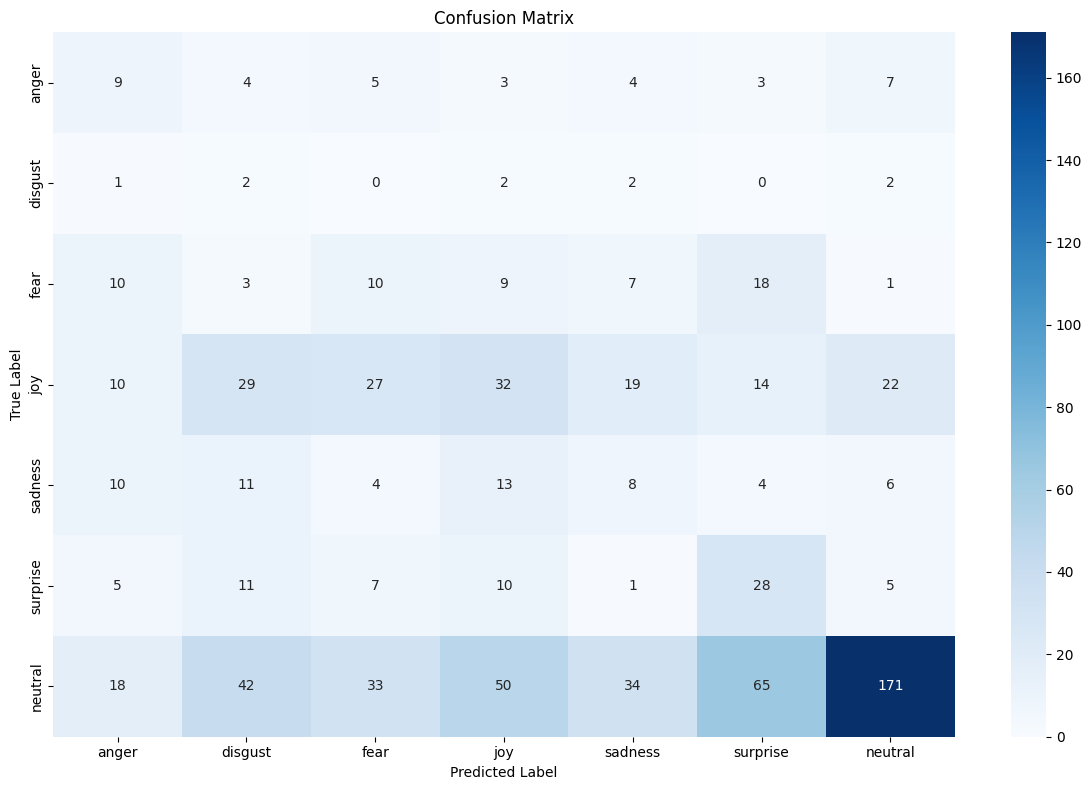

Classification Report:
              precision    recall  f1-score   support

       anger      0.143     0.257     0.184        35
     disgust      0.020     0.222     0.036         9
        fear      0.116     0.172     0.139        58
         joy      0.269     0.209     0.235       153
     sadness      0.107     0.143     0.122        56
    surprise      0.212     0.418     0.281        67
     neutral      0.799     0.414     0.545       413

    accuracy                          0.329       791
   macro avg      0.238     0.262     0.220       791
weighted avg      0.510     0.329     0.382       791


Top 5 Error Patterns: (true → predicted)
------------------------------
neutral → surprise: 65 (12.2% of errors)
neutral → joy: 50 (9.4% of errors)
neutral → disgust: 42 (7.9% of errors)
neutral → sadness: 34 (6.4% of errors)
neutral → fear: 33 (6.2% of errors)

Per-Class Performance:
------------------------------
anger        - P: 0.143, R: 0.257, F1: 0.184, Support:  35, Er

In [37]:
from task6.utils.error_analysis import analyze_classification_errors

results = analyze_classification_errors(
    y_true=y_test,
    y_pred=y_pred,
    class_names=emotions_test,
    sample_texts=df_test["lemmatized_text"],
    model=svm_model,
    X_test=X_test,
    top_k_errors=5
)